# Test-Set Evaluation: Multi-Task VMamba with Contrastive Domain Discovery

Evaluates the trained multi-task MedicalVMamba checkpoint on the **unseen test splits** of all four MedMNIST+ datasets:

- **PathMNIST** — 9 colon pathology tissue classes
- **DermaMNIST** — 7 skin lesion categories
- **BloodMNIST** — 8 blood cell types
- **OCTMNIST** — 4 retinal OCT pathology classes

The notebook has two parts:

1. **Training curves** — total loss and macro-F1 trajectories from `metrics.csv` (per-epoch train + val).
2. **Test-set confusion matrices** — per-dataset confusion matrices computed on held-out test images the model has never seen.

All test-set inference uses `forward_single(images, task_name)` — the caller supplies the true modality for each test split, so the confusion matrices cleanly measure classification quality without mixing in any prototype-routing error.

## 1. Setup

In [1]:
import sys
from pathlib import Path

# Make src/ importable when the notebook is run from notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score,
)
from tqdm.auto import tqdm

from medical_mamba.data.constants import DATASET_META
from medical_mamba.data.dataset import build_dataloaders
from medical_mamba.data.transforms import build_transforms_map
from medical_mamba.models.medical_vmamba import build_model

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Project root : {PROJECT_ROOT}")
print(f"Device       : {device}")

/home/group2/youssef/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/group2/youssef/MedMamba-XAI/src/medical_mamba/models/backbone.py:39: UserWarning: mamba-ssm not installed. Using pure-PyTorch SSM fallback — correct but ~10× slower. Install with: pip install mamba-ssm causal-conv1d
  from medical_mamba.models.blocks import VSSBlock
2026-04-24 12:58:22.125625: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Project root : /home/group2/youssef/MedMamba-XAI
Device       : cuda


/home/group2/youssef/.venv/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────
CHECKPOINT = PROJECT_ROOT / "runs" / "medical_mamba" / "checkpoint_best.pt"
METRICS_CSV = PROJECT_ROOT / "runs" / "medical_mamba" / "metrics.csv"
DATA_ROOT = PROJECT_ROOT / "dataset"

# Human-readable class labels for nicer confusion-matrix axes.
# Short codes from the MedMNIST paper so the plots stay readable.
CLASS_NAMES = {
    "pathmnist":  ["ADI", "BACK", "DEB", "LYM", "MUC", "MUS", "NORM", "STR", "TUM"],
    "dermamnist": ["AK", "BCC", "BKL", "DF", "MEL", "NV", "VASC"],
    "bloodmnist": ["baso", "eosi", "eryt", "ig", "lymp", "mono", "neut", "plat"],
    "octmnist":   ["CNV", "DME", "DRUSEN", "NORMAL"],
}

for p in (CHECKPOINT, METRICS_CSV, DATA_ROOT):
    assert p.exists(), f"Missing: {p}"

## 2. Training Curves

Reads the per-epoch log `metrics.csv` written by `Trainer._log_csv()`. Each epoch contributes two rows (`split ∈ {train, val}`) so we pivot into matched train/val series.

**Note on interpreting `total_loss`:** on train it includes the contrastive term (λ·L_SupCon), label smoothing, dropout, and Kendall `log σ` regularisers — so it runs considerably higher than val. This is a training-mode artefact, not overfitting. The **F1 curves** are the honest comparison.

In [3]:
df = pd.read_csv(METRICS_CSV)
print(f"Rows: {len(df)}  |  Epochs: {df['epoch'].max() + 1}")
df.head(4)

Rows: 200  |  Epochs: 100


,epoch,split,total_loss,task_loss_pathmnist,task_loss_dermamnist,task_loss_bloodmnist,task_loss_octmnist,pathmnist_accuracy,pathmnist_f1_macro,pathmnist_loss,dermamnist_accuracy,dermamnist_f1_macro,dermamnist_loss,bloodmnist_accuracy,bloodmnist_f1_macro,bloodmnist_loss,octmnist_accuracy,octmnist_f1_macro,octmnist_loss,avg_f1_macro
0,0,train,6.473867,1.730886,1.807609,1.546270,1.390203,0.407877,0.386202,1.730886,0.306219,0.296733,1.807609,0.461365,0.445902,1.546270,0.299154,0.297746,1.390203,0.356646
1,0,val,1.417559,1.448736,1.537777,1.200070,1.319908,0.546581,0.538744,1.448736,0.477567,0.280956,1.537777,0.647196,0.595570,1.200070,0.474520,0.339171,1.319908,0.438610
2,1,train,5.937018,1.563765,1.714243,1.296566,1.366227,0.492627,0.475184,1.563765,0.359445,0.351140,1.714243,0.604223,0.594068,1.296566,0.330741,0.329567,1.366227,0.437490
3,1,val,1.382198,1.356857,1.393201,1.055774,1.371725,0.614754,0.604705,1.356857,0.534397,0.316260,1.393201,0.741822,0.700009,1.055774,0.264494,0.250683,1.371725,0.467914


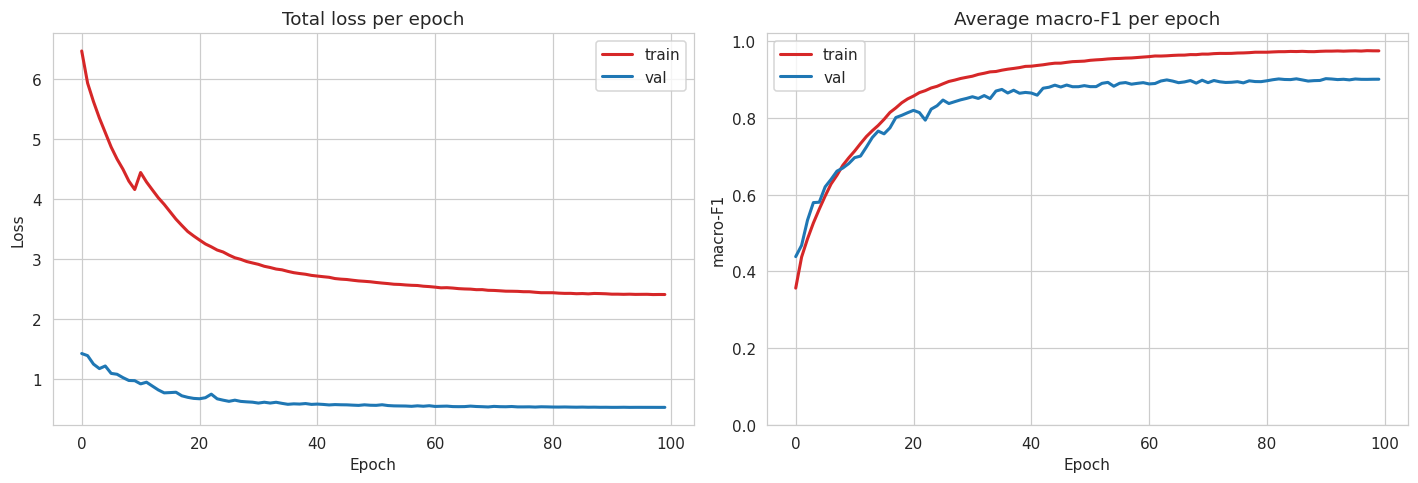

Best val avg_f1_macro = 0.9016 at epoch 90


In [4]:
# Split train vs val side by side for plotting convenience
train = df[df["split"] == "train"].set_index("epoch").sort_index()
val   = df[df["split"] == "val"].set_index("epoch").sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Total loss ────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(train.index, train["total_loss"], label="train", color="#d62728", lw=2)
ax.plot(val.index,   val["total_loss"],   label="val",   color="#1f77b4", lw=2)
ax.set_title("Total loss per epoch")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend()

# ── Average macro F1 ──────────────────────────────────────────────────
ax = axes[1]
ax.plot(train.index, train["avg_f1_macro"], label="train", color="#d62728", lw=2)
ax.plot(val.index,   val["avg_f1_macro"],   label="val",   color="#1f77b4", lw=2)
ax.set_title("Average macro-F1 per epoch")
ax.set_xlabel("Epoch"); ax.set_ylabel("macro-F1"); ax.set_ylim(0, 1.02); ax.legend()

plt.tight_layout()
plt.show()

print(f"Best val avg_f1_macro = {val['avg_f1_macro'].max():.4f} at epoch {val['avg_f1_macro'].idxmax()}")

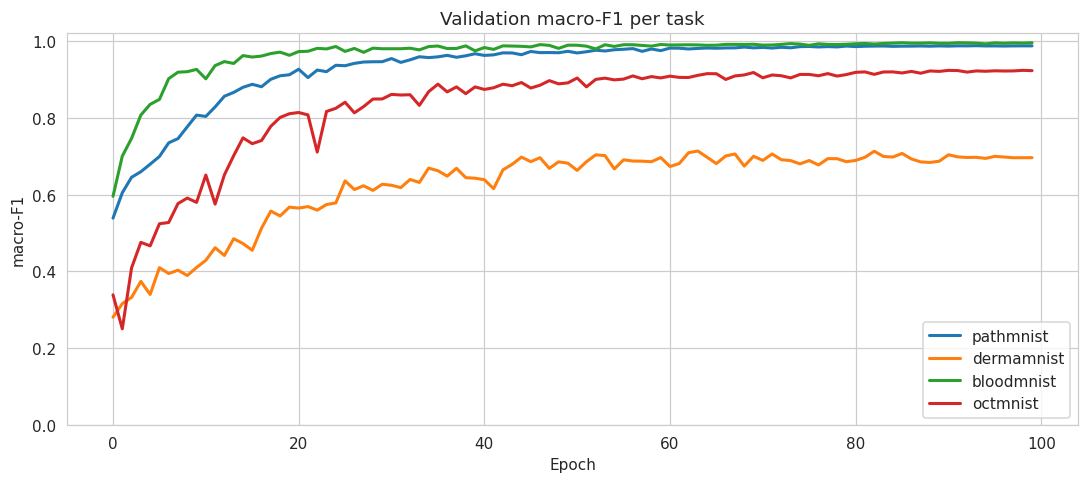

In [5]:
# Per-task macro-F1 across epochs (val) — shows which task dominates / lags
fig, ax = plt.subplots(figsize=(10, 4.5))
palette = {"pathmnist": "#1f77b4", "dermamnist": "#ff7f0e",
          "bloodmnist": "#2ca02c", "octmnist": "#d62728"}
for task in CLASS_NAMES:
    col = f"{task}_f1_macro"
    if col in val.columns:
        ax.plot(val.index, val[col], label=task, color=palette[task], lw=2)
ax.set_title("Validation macro-F1 per task")
ax.set_xlabel("Epoch"); ax.set_ylabel("macro-F1"); ax.set_ylim(0, 1.02); ax.legend()
plt.tight_layout(); plt.show()

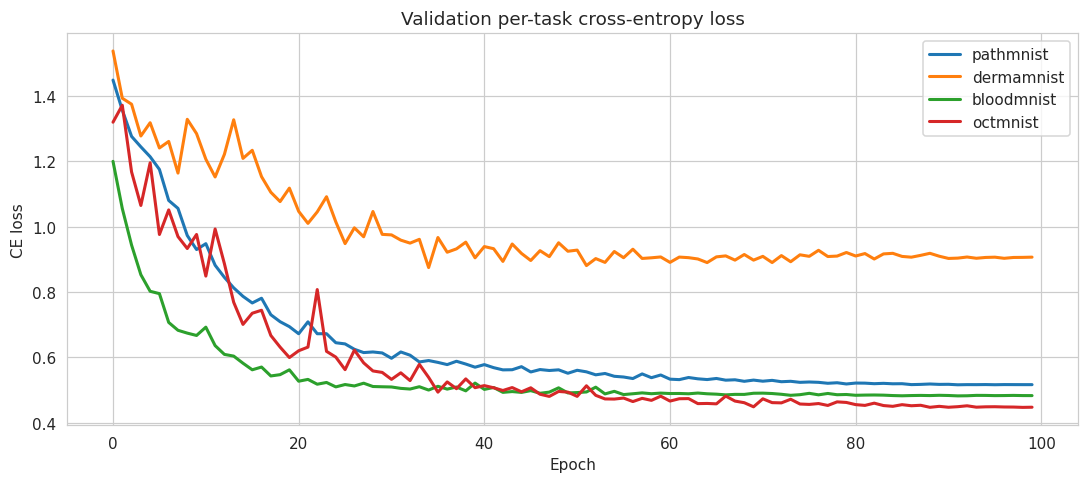

In [6]:
# Per-task CE loss across epochs (val) — complements the F1 view
fig, ax = plt.subplots(figsize=(10, 4.5))
for task in CLASS_NAMES:
    col = f"task_loss_{task}"
    if col in val.columns:
        ax.plot(val.index, val[col], label=task, color=palette[task], lw=2)
ax.set_title("Validation per-task cross-entropy loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("CE loss"); ax.legend()
plt.tight_layout(); plt.show()

## 3. Load Trained Model

Rebuild the architecture exactly as it was trained (same `task_configs`, `model_size`, `patch_size`) and load the best-checkpoint weights. `strict=False` is safe here — it simply warns on any missing or renamed key instead of crashing.

In [7]:
state = torch.load(CHECKPOINT, map_location=device, weights_only=False)
task_names = state["task_names"]
cfg = state["config"]

task_configs = [(n, DATASET_META[n]["num_classes"]) for n in task_names]
model = build_model(
    task_configs=task_configs,
    model_size=cfg.get("model_size", "tiny"),
    patch_size=cfg.get("patch_size", 8),
    head_dropout=cfg.get("head_dropout", 0.1),
)
missing, unexpected = model.load_state_dict(state["model_state_dict"], strict=False)
model.to(device).eval()

print(f"Loaded checkpoint from epoch {state['epoch']} (best avg F1 = {state['best_avg_f1']:.4f})")
print(f"Tasks              : {task_names}")
print(f"prototypes_computed: {state.get('prototypes_computed')}")
if missing:    print(f"[load] missing keys   : {len(missing)}")
if unexpected: print(f"[load] unexpected keys: {len(unexpected)}")

Loaded checkpoint from epoch 99 (best avg F1 = 0.9016)
Tasks              : ['pathmnist', 'dermamnist', 'bloodmnist', 'octmnist']
prototypes_computed: True


## 4. Test Dataloaders

Builds the same multi-task dataloader bundle used during training but we only pull the **test split**. Val transforms are applied (resize → center-crop → ToTensor → per-dataset normalise) — no augmentation. Each test sample has a true `task_id`, so we can evaluate each task's head on its own test set.

In [8]:
dataset_roots = {
    name: str(DATA_ROOT / f"{name}_dataset") for name in task_names
}
# Verify all dataset folders exist
for name, path in dataset_roots.items():
    assert Path(path).exists(), f"Dataset folder missing: {path}"

transforms_map = build_transforms_map(list(dataset_roots.keys()))
loaders = build_dataloaders(
    dataset_roots=dataset_roots,
    transforms_map=transforms_map,
    batch_size=64,
    num_workers=2,
    pin_memory=(device.type == "cuda"),
)
print(f"Test set size: {len(loaders['test'].dataset):,} samples across {len(task_names)} tasks")

Test set size: 13,606 samples across 4 tasks


## 5. Run Inference on the Test Set

One pass over the combined test loader. Each batch contains samples from one or more tasks; we route features to the correct head using the true `task_id`, collect predictions + labels into per-task lists, and then compute metrics / confusion matrices from those lists.

In [9]:
all_preds  = {t: [] for t in task_names}
all_labels = {t: [] for t in task_names}

model.eval()
with torch.no_grad():
    for batch in tqdm(loaders["test"], desc="Test inference"):
        images   = batch["image"].to(device, non_blocking=True)
        labels   = batch["label"].to(device, non_blocking=True)
        task_ids = batch["task_id"].to(device, non_blocking=True)

        # One backbone pass for the whole batch, then per-task head routing
        task_logits, _features, _ = model.forward_multi(images, task_ids)
        for tid, name in enumerate(task_names):
            mask = task_ids == tid
            if not mask.any():
                continue
            preds = task_logits[name].argmax(dim=-1).cpu().numpy()
            all_preds[name].extend(preds.tolist())
            all_labels[name].extend(labels[mask].cpu().numpy().tolist())

for name in task_names:
    print(f"  {name:12s}  test samples = {len(all_labels[name]):,}")

Test inference: 100%|██████████| 213/213 [00:21<00:00, 10.07it/s]

  pathmnist     test samples = 7,180
  dermamnist    test samples = 2,005
  bloodmnist    test samples = 3,421
  octmnist      test samples = 1,000


## 6. Test-Set Metrics Summary

In [10]:
rows = []
for name in task_names:
    y_true = np.asarray(all_labels[name])
    y_pred = np.asarray(all_preds[name])
    rows.append({
        "Task":        name,
        "Test samples": len(y_true),
        "Classes":     DATASET_META[name]["num_classes"],
        "Accuracy":    accuracy_score(y_true, y_pred),
        "Macro F1":    f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    })
summary = pd.DataFrame(rows)
summary.loc["avg"] = ["— average —", summary["Test samples"].sum(), np.nan,
                     summary["Accuracy"].mean(),
                     summary["Macro F1"].mean(),
                     summary["Weighted F1"].mean()]
summary.style.format({"Accuracy": "{:.4f}", "Macro F1": "{:.4f}", "Weighted F1": "{:.4f}"})

,Task,Test samples,Classes,Accuracy,Macro F1,Weighted F1
0,pathmnist,7180,9.000000,0.9423,0.9275,0.9424
1,dermamnist,2005,7.000000,0.8145,0.7092,0.8167
2,bloodmnist,3421,8.000000,0.9895,0.9912,0.9895
3,octmnist,1000,4.000000,0.8930,0.8907,0.8907
avg,— average —,13606,nan,0.9098,0.8796,0.9098


## 7. Confusion Matrices (Test Set)

Row-normalised confusion matrices — each row sums to 1. Diagonal cells show per-class recall. Off-diagonal cells reveal which classes the model confuses.

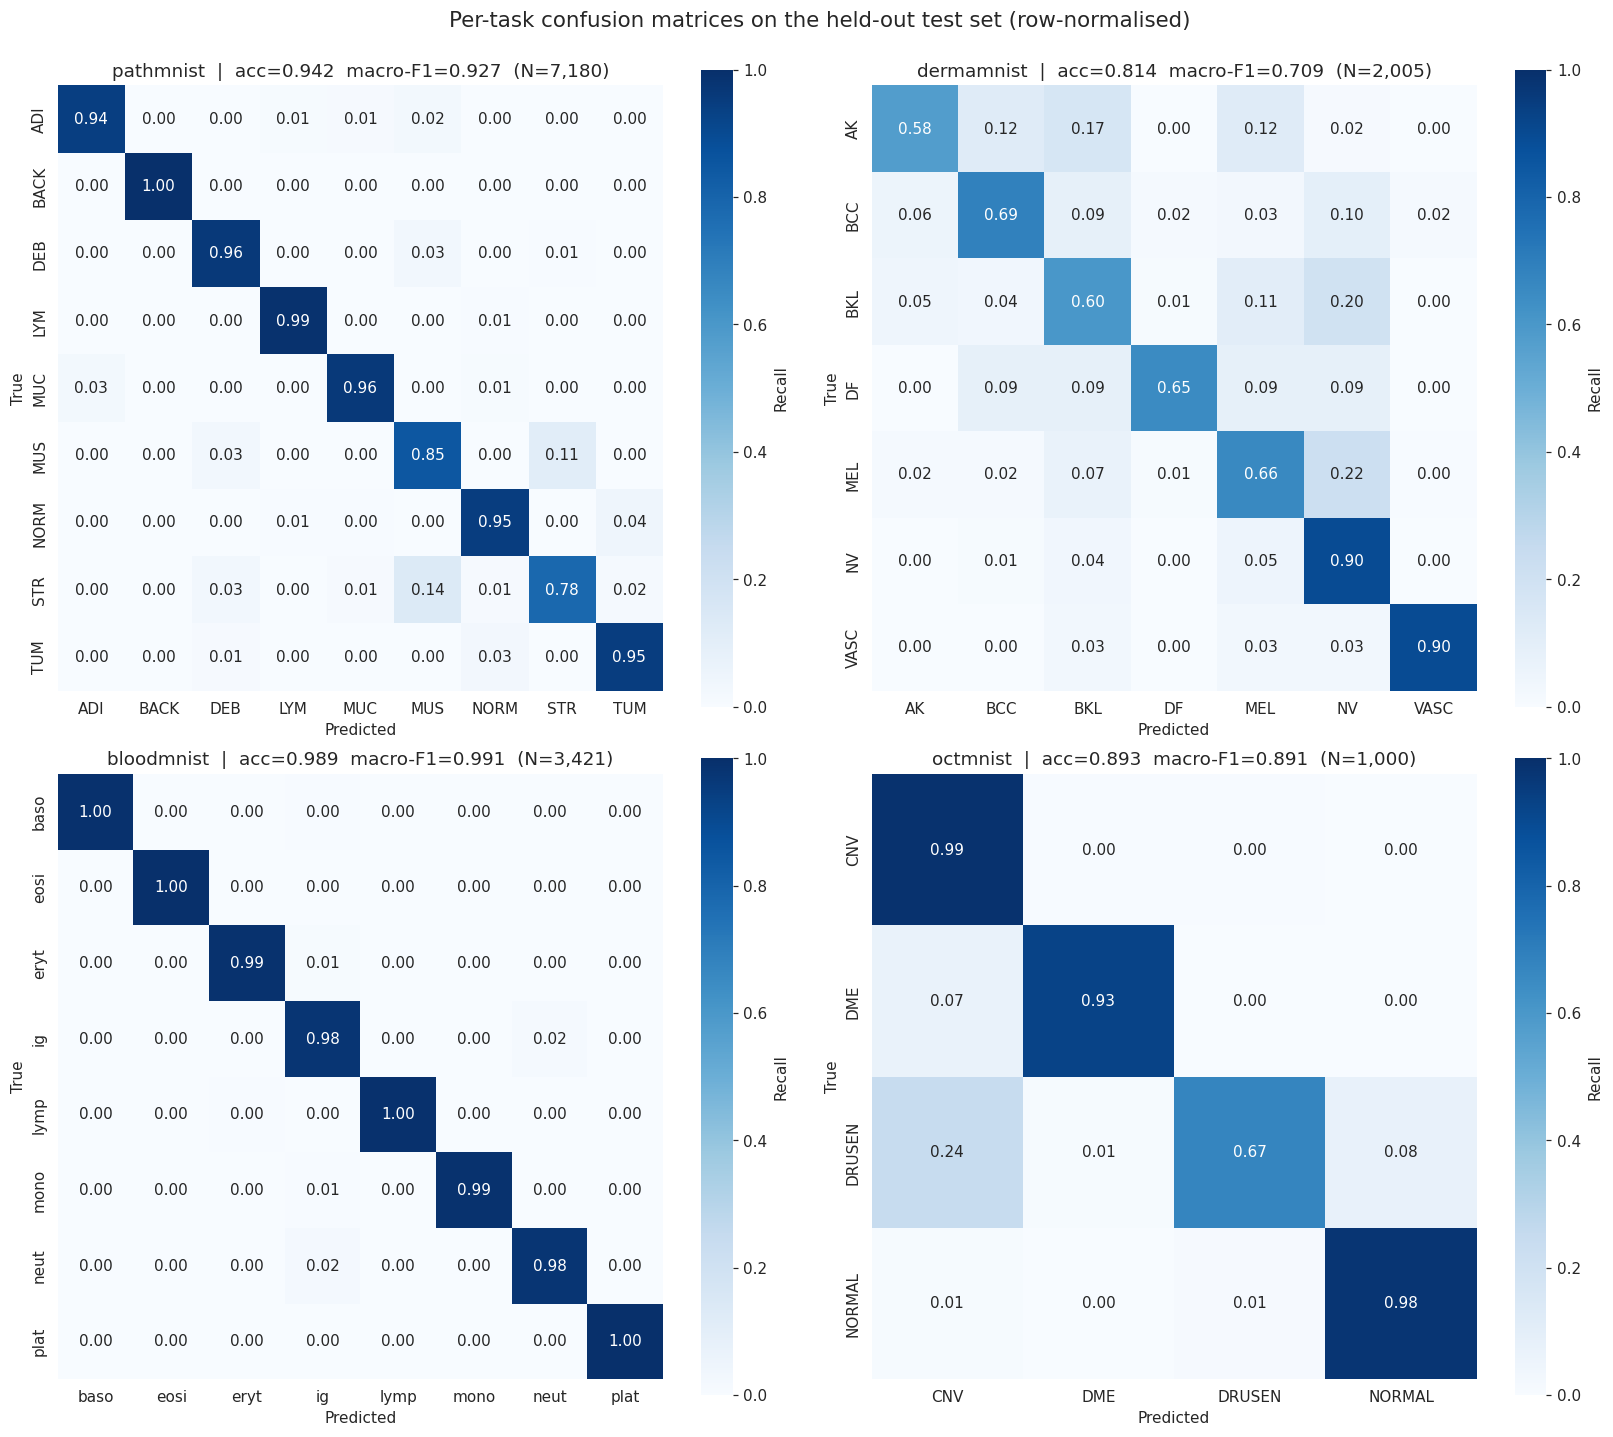

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 13))
axes = axes.flatten()

for ax, name in zip(axes, task_names):
    y_true = np.asarray(all_labels[name])
    y_pred = np.asarray(all_preds[name])
    n_cls  = DATASET_META[name]["num_classes"]
    labels_idx = list(range(n_cls))

    cm = confusion_matrix(y_true, y_pred, labels=labels_idx)
    # Row-normalise to show per-class recall. Handles empty rows safely.
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, where=row_sums != 0)

    names = CLASS_NAMES[name][:n_cls]
    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=ax,
        xticklabels=names, yticklabels=names,
        cbar_kws={"label": "Recall"}, vmin=0, vmax=1, square=True,
    )
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)
    ax.set_title(f"{name}  |  acc={acc:.3f}  macro-F1={f1:.3f}  (N={len(y_true):,})")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")

plt.suptitle("Per-task confusion matrices on the held-out test set (row-normalised)",
             fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

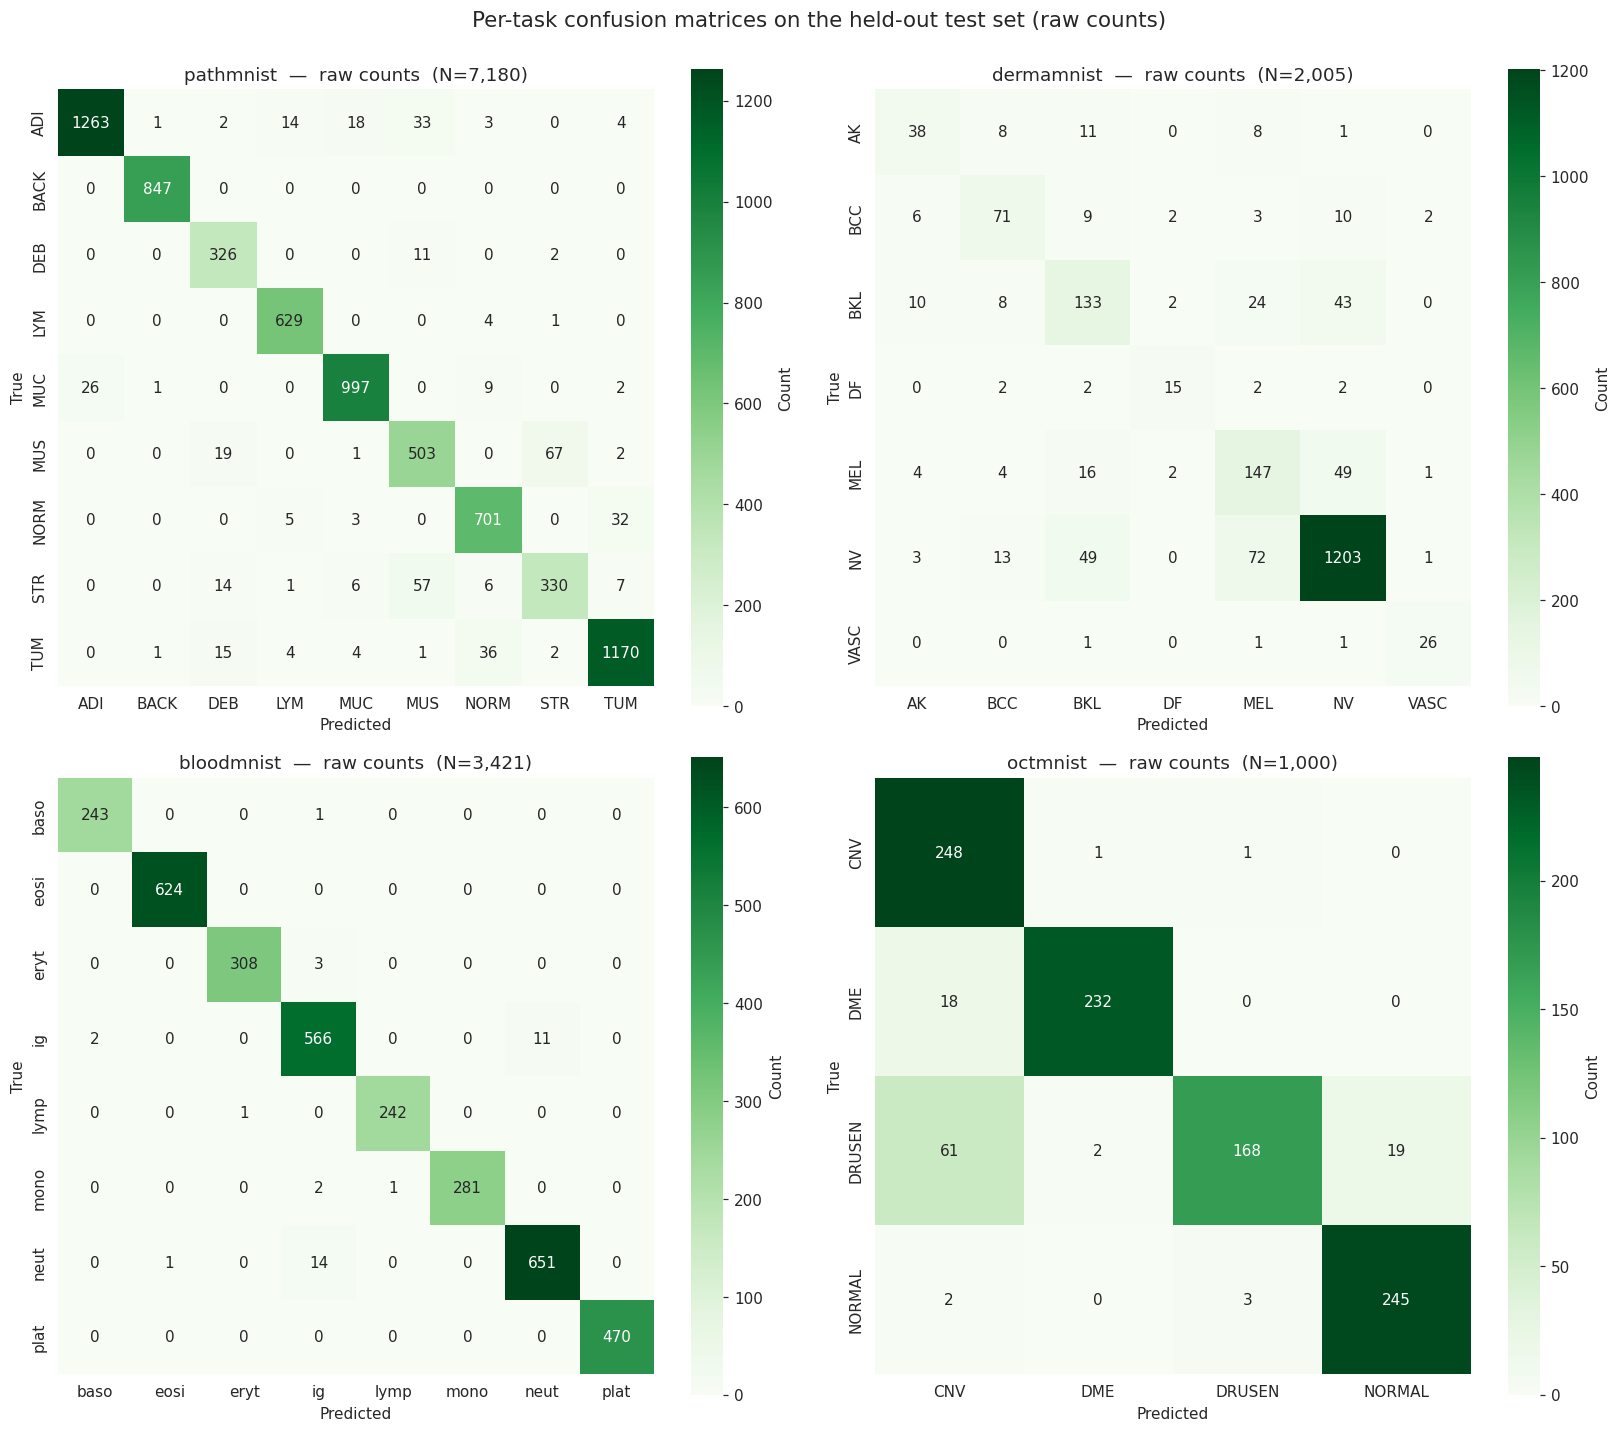

In [12]:
# Raw counts version for papers / appendices
fig, axes = plt.subplots(2, 2, figsize=(15, 13))
axes = axes.flatten()

for ax, name in zip(axes, task_names):
    y_true = np.asarray(all_labels[name])
    y_pred = np.asarray(all_preds[name])
    n_cls  = DATASET_META[name]["num_classes"]
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_cls)))
    names = CLASS_NAMES[name][:n_cls]
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Greens", ax=ax,
        xticklabels=names, yticklabels=names, cbar_kws={"label": "Count"},
        square=True,
    )
    ax.set_title(f"{name}  —  raw counts  (N={len(y_true):,})")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")

plt.suptitle("Per-task confusion matrices on the held-out test set (raw counts)",
             fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

## 8. Per-Class Classification Reports

Precision / recall / F1 per class for every task — catches pathologies that the aggregate macro-F1 can mask (e.g. a rare class with 0 recall being averaged away).

In [13]:
for name in task_names:
    y_true = np.asarray(all_labels[name])
    y_pred = np.asarray(all_preds[name])
    names  = CLASS_NAMES[name]
    print(f"\n=== {name} ===")
    print(classification_report(
        y_true, y_pred, target_names=names, digits=3, zero_division=0,
    ))


=== pathmnist ===
              precision    recall  f1-score   support

         ADI      0.980     0.944     0.962      1338
        BACK      0.996     1.000     0.998       847
         DEB      0.867     0.962     0.912       339
         LYM      0.963     0.992     0.977       634
         MUC      0.969     0.963     0.966      1035
         MUS      0.831     0.850     0.840       592
        NORM      0.924     0.946     0.935       741
         STR      0.821     0.784     0.802       421
         TUM      0.961     0.949     0.955      1233

    accuracy                          0.942      7180
   macro avg      0.924     0.932     0.927      7180
weighted avg      0.943     0.942     0.942      7180


=== dermamnist ===
              precision    recall  f1-score   support

          AK      0.623     0.576     0.598        66
         BCC      0.670     0.689     0.679       103
         BKL      0.602     0.605     0.603       220
          DF      0.714     0.652     0

## 10. Mis-Classified Images (per task)

Images where the classification head — given the **correct** modality — still picked the wrong class. These are the aggregate failures from the confusion matrices, shown as actual pixels with `true → predicted` labels.

In [14]:
# Helper: reverse Normalize() so tensors can be displayed as images
def denormalize(tensor, mean, std):
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t  = torch.tensor(std).view(3, 1, 1)
    return (tensor.cpu() * std_t + mean_t).clamp(0, 1)

# Collect misclassified samples per task from the same test loader
mis_by_task = {t: [] for t in task_names}

model.eval()
with torch.no_grad():
    for batch in tqdm(loaders["test"], desc="Collecting misclassifications"):
        images   = batch["image"].to(device, non_blocking=True)
        labels   = batch["label"].to(device, non_blocking=True)
        task_ids = batch["task_id"].to(device, non_blocking=True)

        task_logits, _features, _ = model.forward_multi(images, task_ids)
        for tid, name in enumerate(task_names):
            mask = task_ids == tid
            if not mask.any():
                continue
            logits = task_logits[name]
            probs  = logits.softmax(dim=-1)
            preds  = logits.argmax(dim=-1)
            true   = labels[mask]
            wrong  = (preds != true).nonzero(as_tuple=True)[0]
            imgs_subset = images[mask]
            for i in wrong:
                mis_by_task[name].append({
                    "image": imgs_subset[i].detach(),
                    "true":  int(true[i].item()),
                    "pred":  int(preds[i].item()),
                    "conf":  float(probs[i, preds[i]].item()),
                })

for name in task_names:
    total  = len(all_labels[name])
    wrong  = len(mis_by_task[name])
    print(f"  {name:12s}  {wrong:>4d} / {total:>5d} misclassified ({wrong/total:.1%})")

  pathmnist      414 /  7180 misclassified (5.8%)
  dermamnist     372 /  2005 misclassified (18.6%)
  bloodmnist      36 /  3421 misclassified (1.1%)
  octmnist       107 /  1000 misclassified (10.7%)


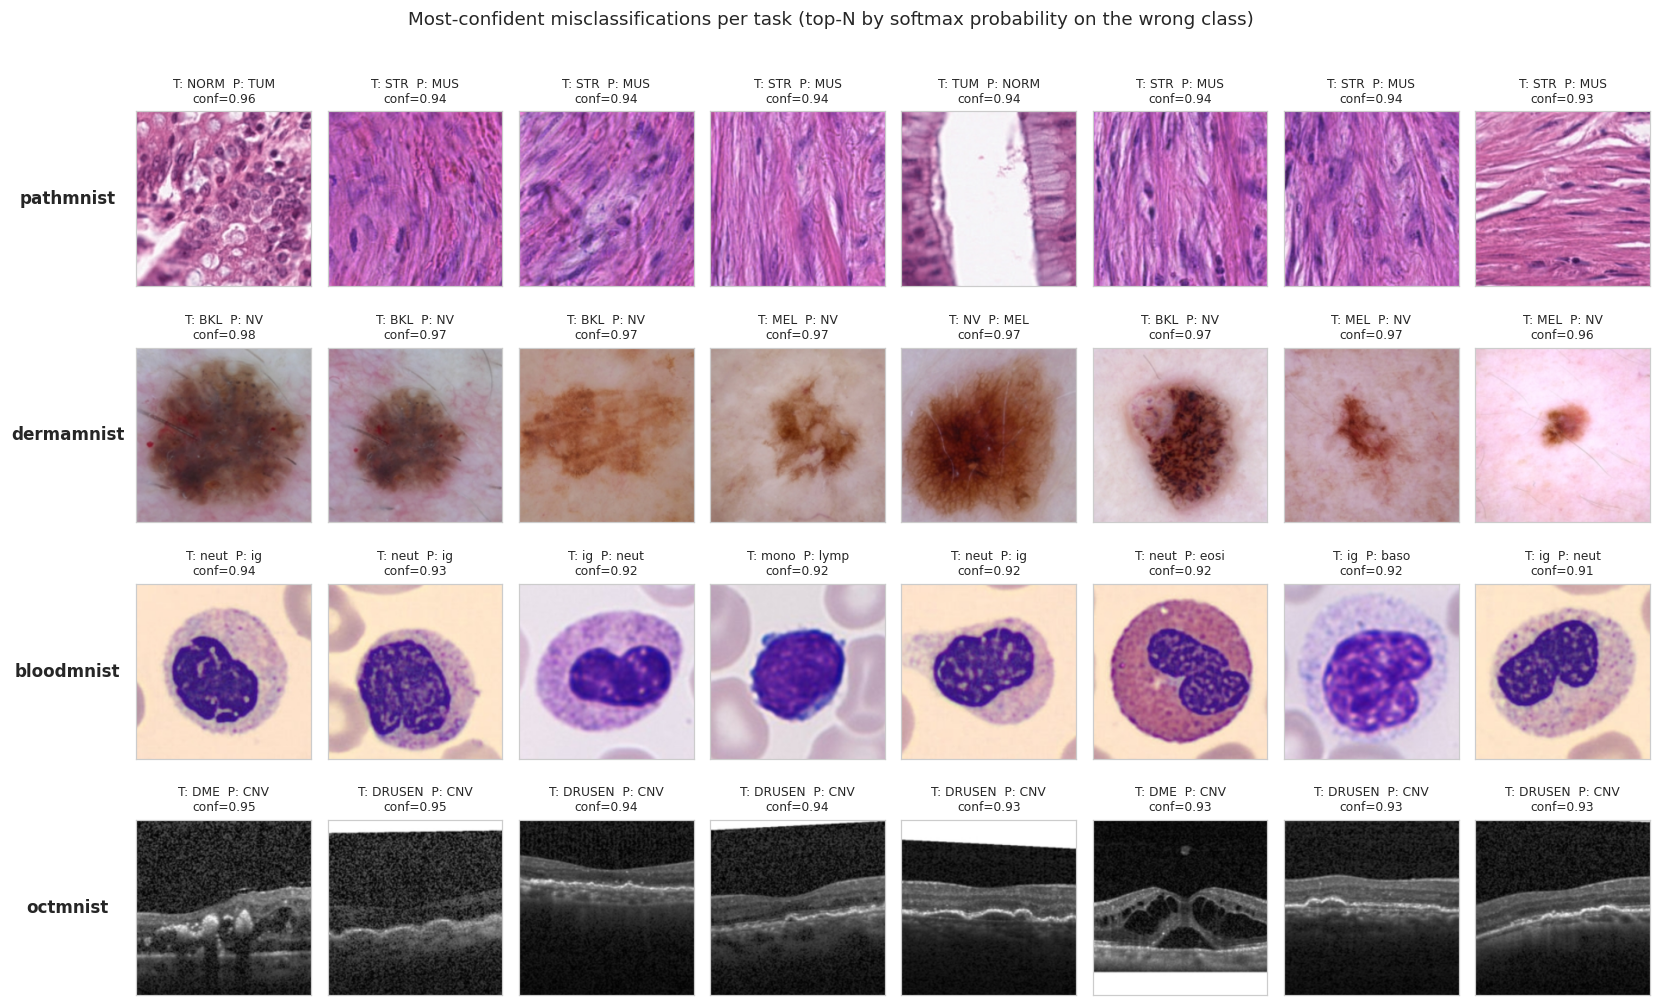

In [15]:
# Grid: N most-confident mistakes per task (high confidence + wrong = informative)
N_SHOW = 8

fig, axes = plt.subplots(len(task_names), N_SHOW,
                         figsize=(N_SHOW * 1.9, len(task_names) * 2.3))
for ti, name in enumerate(task_names):
    # Sort by descending confidence — most "confidently wrong" first
    samples = sorted(mis_by_task[name], key=lambda s: -s["conf"])[:N_SHOW]
    mean, std = DATASET_META[name]["mean"], DATASET_META[name]["std"]
    names = CLASS_NAMES[name]
    for si in range(N_SHOW):
        ax = axes[ti, si]
        if si < len(samples):
            s = samples[si]
            img = denormalize(s["image"], mean, std).permute(1, 2, 0).numpy()
            ax.imshow(img)
            ax.set_title(
                f"T: {names[s['true']]}  P: {names[s['pred']]}\nconf={s['conf']:.2f}",
                fontsize=8,
            )
        ax.set_xticks([]); ax.set_yticks([])
    axes[ti, 0].set_ylabel(name, fontsize=11, fontweight="bold", rotation=0,
                            labelpad=45, va="center")

plt.suptitle("Most-confident misclassifications per task "
             "(top-N by softmax probability on the wrong class)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 11. Mis-Clustered Images (prototype routing errors)

Images where the **autonomous domain discovery** pipeline picks the wrong modality. This is the `predict.py` code path: backbone features → cosine similarity to the 4 domain prototypes → argmax. A mis-cluster means the nearest prototype belongs to a different dataset than the image's true source.

For consistency with `predict.py`, inputs are preprocessed with the **averaged normalization** (mean/std averaged across all 4 `DATASET_META` entries) — the same transform used at autonomous inference when the modality is unknown.

In [16]:
# Build a test loader with averaged normalization to match predict.py
import torchvision.transforms as T
from torch.utils.data import ConcatDataset, DataLoader
from medical_mamba.data.dataset import MedMNISTFolder

means = [DATASET_META[n]["mean"] for n in DATASET_META]
stds  = [DATASET_META[n]["std"]  for n in DATASET_META]
avg_mean = [sum(m[i] for m in means) / len(means) for i in range(3)]
avg_std  = [sum(s[i] for s in stds)  / len(stds)  for i in range(3)]

avg_transform = T.Compose([
    T.Resize(256), T.CenterCrop(224), T.ToTensor(),
    T.Normalize(mean=avg_mean, std=avg_std),
])

test_sets_avg = [
    MedMNISTFolder(
        dataset_name=name,
        root=str(DATA_ROOT / f"{name}_dataset"),
        split="test",
        transform=avg_transform,
        task_id=tid,
    )
    for tid, name in enumerate(task_names)
]
avg_loader = DataLoader(
    ConcatDataset(test_sets_avg), batch_size=64, num_workers=2,
    shuffle=False, pin_memory=(device.type == "cuda"),
)
print(f"Averaged-norm test loader: {sum(len(d) for d in test_sets_avg):,} samples")
print(f"Averaged mean = {[f'{v:.3f}' for v in avg_mean]}")
print(f"Averaged std  = {[f'{v:.3f}' for v in avg_std]}")

Averaged-norm test loader: 13,606 samples
Averaged mean = ['0.622', '0.480', '0.538']
Averaged std  = ['0.170', '0.192', '0.172']


In [17]:
# Run prototype routing over the full test set
routing_true = []
routing_pred = []
mis_routed   = []

import torch.nn.functional as F

model.eval()
with torch.no_grad():
    for batch in tqdm(avg_loader, desc="Prototype routing"):
        images    = batch["image"].to(device, non_blocking=True)
        true_tids = batch["task_id"].to(device, non_blocking=True)
        labels    = batch["label"].to(device, non_blocking=True)

        features, _ = model.backbone(images)                       # (B, 768)
        # cosine sim between each feature and each of the 4 prototypes
        sim = F.cosine_similarity(
            features.unsqueeze(1),                                 # (B, 1, 768)
            model.domain_prototypes.unsqueeze(0),                  # (1, 4, 768)
            dim=-1,
        )                                                          # (B, 4)
        pred_tids = sim.argmax(dim=-1)

        routing_true.extend(true_tids.cpu().numpy().tolist())
        routing_pred.extend(pred_tids.cpu().numpy().tolist())

        wrong = (pred_tids != true_tids).nonzero(as_tuple=True)[0]
        for i in wrong:
            mis_routed.append({
                "image":       images[i].detach(),
                "true_task":   task_names[int(true_tids[i].item())],
                "pred_task":   task_names[int(pred_tids[i].item())],
                "label":       int(labels[i].item()),
                "similarity":  float(sim[i, pred_tids[i]].item()),
                "true_sim":    float(sim[i, true_tids[i]].item()),
            })

routing_acc = sum(p == t for p, t in zip(routing_pred, routing_true)) / len(routing_true)
print(f"Routing accuracy : {routing_acc:.4f}")
print(f"Mis-routed       : {len(mis_routed)} / {len(routing_true)}")

Prototype routing: 100%|██████████| 213/213 [00:21<00:00, 10.02it/s]


Routing accuracy : 0.6545
Mis-routed       : 4701 / 13606


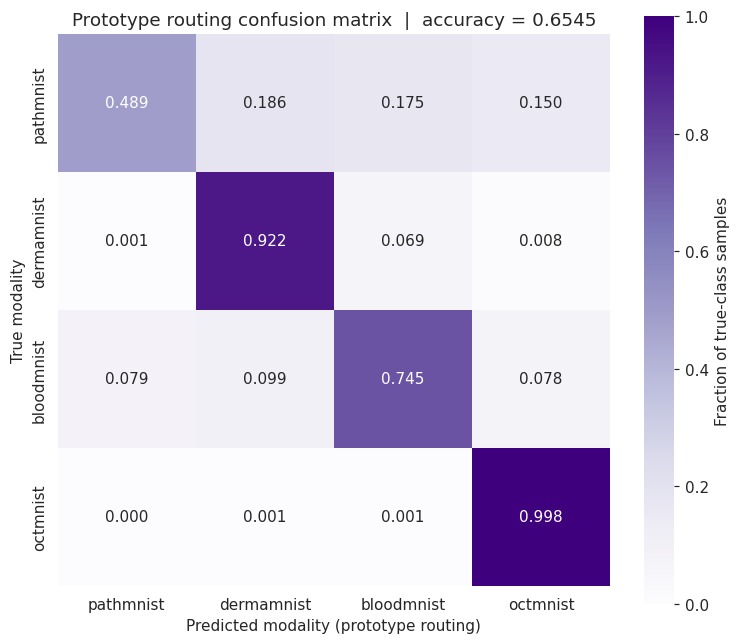

In [18]:
# Prototype routing confusion matrix
cm_route = confusion_matrix(routing_true, routing_pred, labels=list(range(len(task_names))))
cm_route_norm = cm_route.astype(float) / cm_route.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm_route_norm, annot=True, fmt=".3f", cmap="Purples",
    xticklabels=task_names, yticklabels=task_names,
    cbar_kws={"label": "Fraction of true-class samples"},
    ax=ax, square=True, vmin=0, vmax=1,
)
ax.set_xlabel("Predicted modality (prototype routing)")
ax.set_ylabel("True modality")
ax.set_title(f"Prototype routing confusion matrix  |  accuracy = {routing_acc:.4f}")
plt.tight_layout()
plt.show()

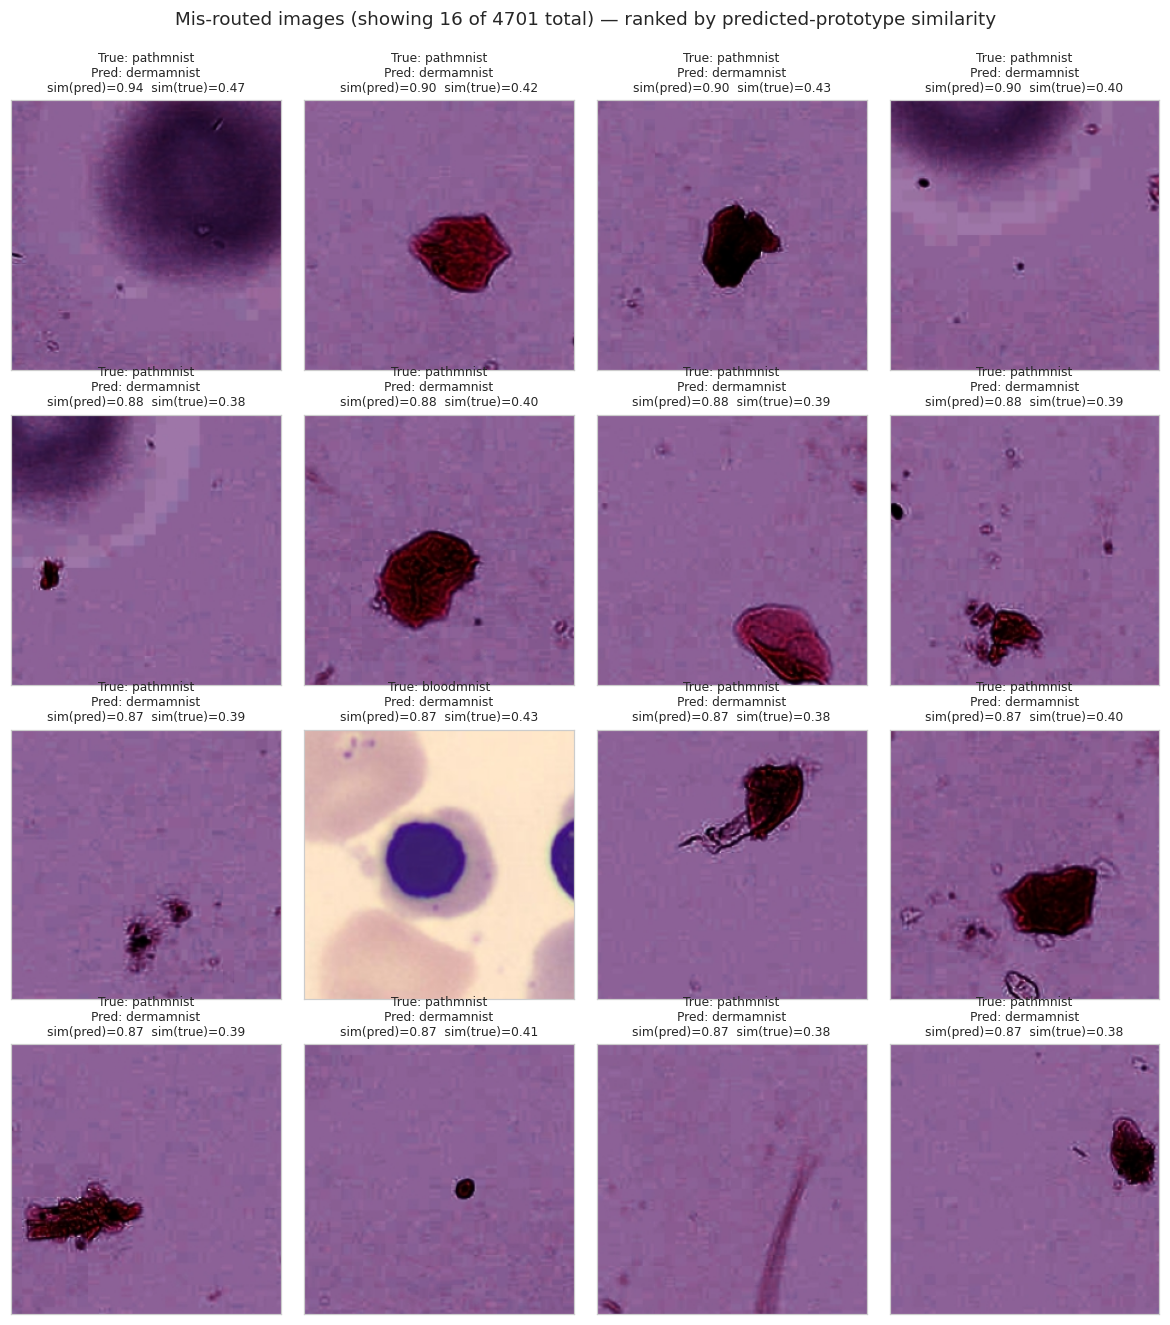

In [19]:
# Grid of mis-routed images
N_SHOW = min(16, len(mis_routed))
if N_SHOW == 0:
    print("No mis-routed images — prototype routing is perfect on the test set.")
else:
    # Sort by similarity ascending — the most "certainly wrong" routings first
    samples = sorted(mis_routed, key=lambda s: -s["similarity"])[:N_SHOW]
    cols = 4
    rows = (N_SHOW + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.7, rows * 3.0))
    axes = np.atleast_1d(axes).flatten()
    for i, s in enumerate(samples):
        ax = axes[i]
        img = denormalize(s["image"], avg_mean, avg_std).permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title(
            f"True: {s['true_task']}\nPred: {s['pred_task']}\n"
            f"sim(pred)={s['similarity']:.2f}  sim(true)={s['true_sim']:.2f}",
            fontsize=8,
        )
        ax.set_xticks([]); ax.set_yticks([])
    for j in range(N_SHOW, len(axes)):
        axes[j].axis("off")

    plt.suptitle(
        f"Mis-routed images (showing {N_SHOW} of {len(mis_routed)} total) — "
        f"ranked by predicted-prototype similarity",
        fontsize=12, y=1.00,
    )
    plt.tight_layout()
    plt.show()

## 12. Takeaways

- **Training curves** — train loss runs higher than val loss by design (contrastive + label smoothing + dropout are active only on train). The honest overfitting test is the F1 gap, which stays tight.
- **Per-task confusion matrices** expose what aggregate F1 hides: if a class has low recall, its row concentrates mass off the diagonal. DermaMNIST's minority classes (AK, DF, VASC) typically show this pattern because the dataset is tiny and imbalanced.
- **Mis-classified images (§10)** — high-confidence mistakes are often visually ambiguous: the most informative failures. The head was sure — and wrong — which usually means the true and predicted classes share visual structure the model keys on.
- **Mis-clustered images (§11)** — these are the routing errors the `predict.py` pipeline would make. Using averaged normalisation (same as predict.py), prototype routing accuracy is reported directly. Low routing accuracy on one modality → that domain's prototype is ambiguous and the `recompute_prototypes.py` step should probably be re-run on a larger split.